In [1]:
%pip install -q opencv-python scikit-image seaborn scikit-learn matplotlib

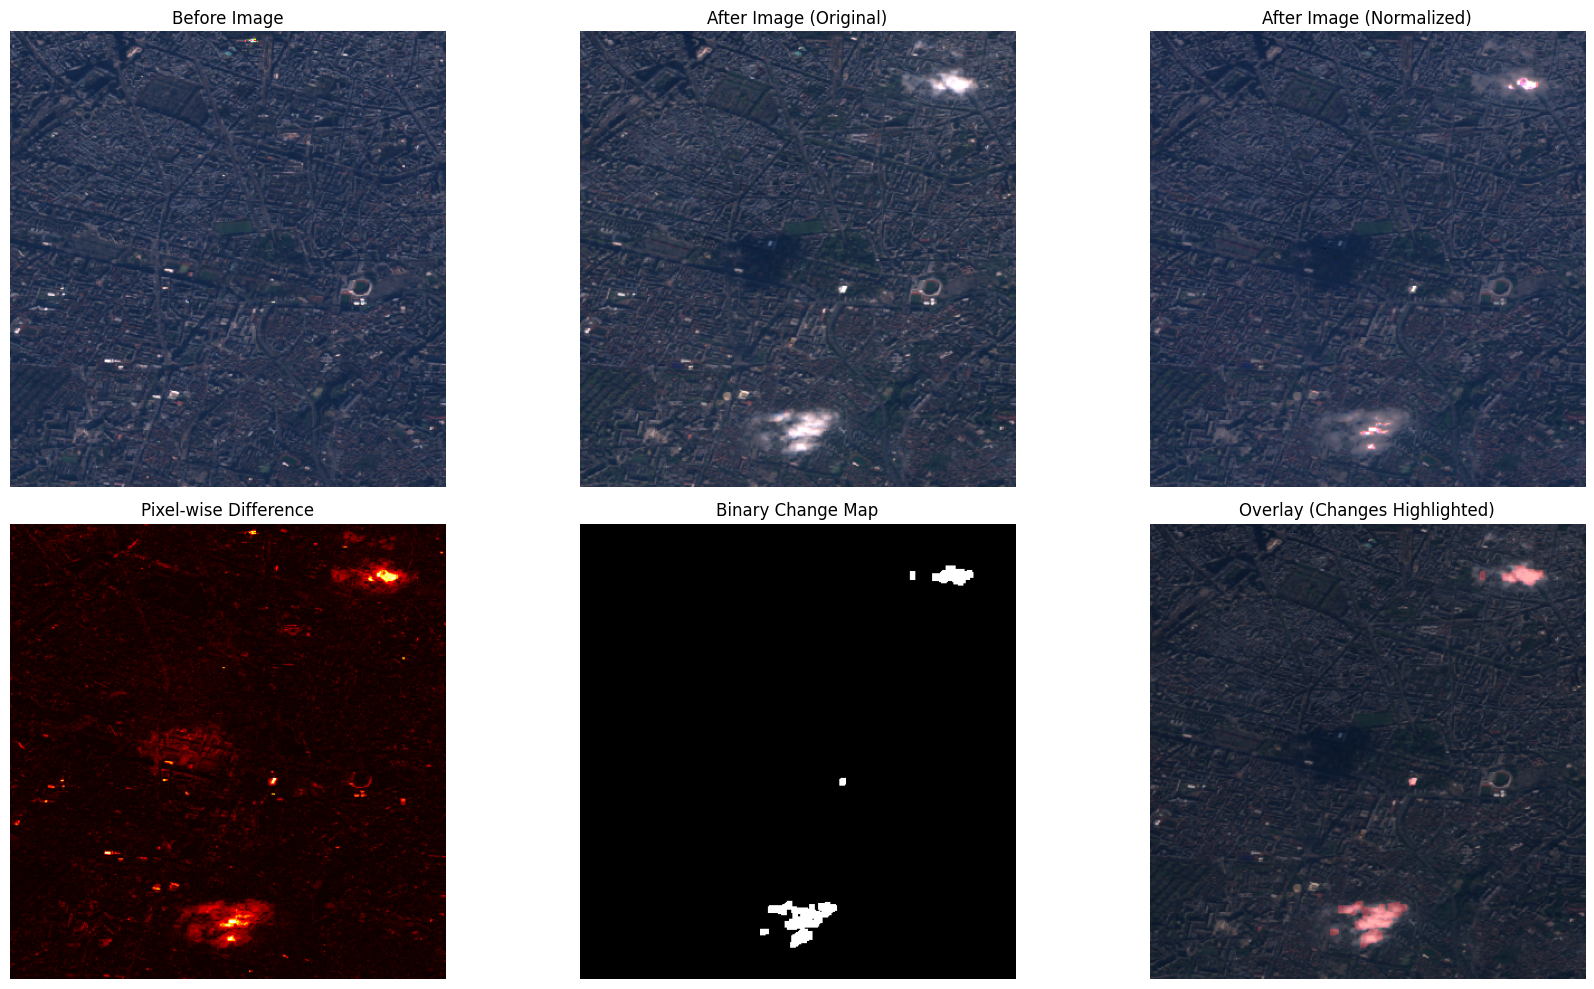

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

# ----------------------------------
# Paths (adjust if needed)
# ----------------------------------
before_path = "../content/img1.png"
after_path  = "../content/img2.png"

# ----------------------------------
# 1. Load images
# ----------------------------------
img_before = cv2.imread(before_path)
img_after  = cv2.imread(after_path)

if img_before is None or img_after is None:
    raise ValueError(" Image paths are wrong")

img_before = cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB)
img_after  = cv2.cvtColor(img_after,  cv2.COLOR_BGR2RGB)

# ----------------------------------
# 2. Histogram matching (color normalization)
# ----------------------------------
img_after_norm = match_histograms(
    img_after,
    img_before,
    channel_axis=-1
)

# ----------------------------------
# 3. Pixel-wise absolute difference
# ----------------------------------
diff = np.abs(
    img_before.astype(np.float32) -
    img_after_norm.astype(np.float32)
)

# Convert to grayscale difference
diff_gray = diff.mean(axis=2)

# ----------------------------------
# 4. Normalize difference map to [0,1]
# ----------------------------------
diff_norm = (diff_gray - diff_gray.min()) / (
    diff_gray.max() - diff_gray.min() + 1e-6
)

# ----------------------------------
# 5. Threshold (tune if needed)
# ----------------------------------
THRESHOLD = 0.15   # try 0.10 – 0.20
change_map = (diff_norm > THRESHOLD).astype(np.uint8)

# ----------------------------------
# 6. Morphological cleanup
# ----------------------------------
kernel = np.ones((5, 5), np.uint8)
change_map = cv2.morphologyEx(change_map, cv2.MORPH_OPEN, kernel)

# ----------------------------------
# 7. Visualization
# ----------------------------------
change_color = np.zeros((*change_map.shape, 3), dtype=np.uint8)
change_color[change_map == 1] = [255, 0, 0]  # red = change

overlay = (0.7 * img_after + 0.3 * change_color).astype(np.uint8)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.title("Before Image")
plt.imshow(img_before)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("After Image (Original)")
plt.imshow(img_after)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("After Image (Normalized)")
plt.imshow(img_after_norm)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Pixel-wise Difference")
plt.imshow(diff_norm, cmap="hot")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Binary Change Map")
plt.imshow(change_map, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Overlay (Changes Highlighted)")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
import os

output_dir = "/content/results"
os.makedirs(output_dir, exist_ok=True)


In [5]:
import cv2

# Assume these already exist in memory
# img_before, img_after, overlay  (RGB format)

cv2.imwrite(
    os.path.join(output_dir, "before.png"),
    cv2.cvtColor(img_before, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    os.path.join(output_dir, "after.png"),
    cv2.cvtColor(img_after, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    os.path.join(output_dir, "overlay.png"),
    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
)


True

In [6]:
# change_map should be 0/1
change_map_uint8 = (change_map * 255).astype("uint8")

cv2.imwrite(
    os.path.join(output_dir, "pred_change.png"),
    change_map_uint8
)


True

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
gt_path   = "../content/cm.png"        # ground truth
pred_path = "../content/results/pred_change.png"      # your predicted mask

# -----------------------------
# Load masks
# -----------------------------
gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

if gt is None or pred is None:
    raise ValueError(" Check GT or prediction path")

# -----------------------------
# Ensure binary (0,1)
# -----------------------------
gt   = (gt > 0).astype(np.uint8)
pred = (pred > 0).astype(np.uint8)

print("GT unique values:", np.unique(gt))
print("Pred unique values:", np.unique(pred))


GT unique values: [0 1]
Pred unique values: [0 1]


In [8]:
# True Positive, False Positive, False Negative
TP = np.sum((pred == 1) & (gt == 1))
FP = np.sum((pred == 1) & (gt == 0))
FN = np.sum((pred == 0) & (gt == 1))
TN = np.sum((pred == 0) & (gt == 0))

print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")

# Metrics
precision = TP / (TP + FP + 1e-6)
recall    = TP / (TP + FN + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)
iou       = TP / (TP + FP + FN + 1e-6)


print("📊 Evaluation Metrics")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"IoU:       {iou:.4f}")


TP: 36, FP: 1623, FN: 422, TN: 157039
📊 Evaluation Metrics
Precision: 0.0217
Recall:    0.0786
F1-score:  0.0340
IoU:       0.0173


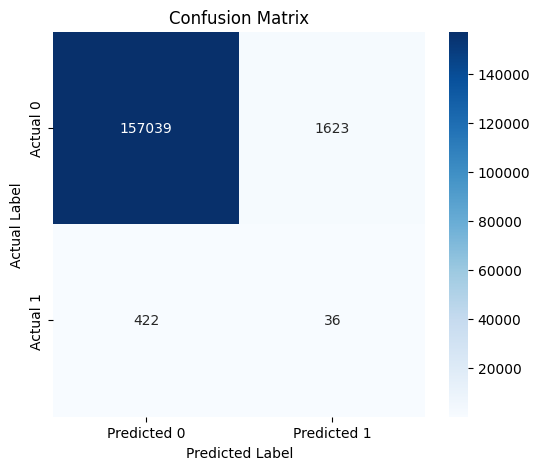

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Flatten the ground truth and prediction masks
gt_flat = gt.flatten()
pred_flat = pred.flatten()

# Calculate the confusion matrix
cm = confusion_matrix(gt_flat, pred_flat)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

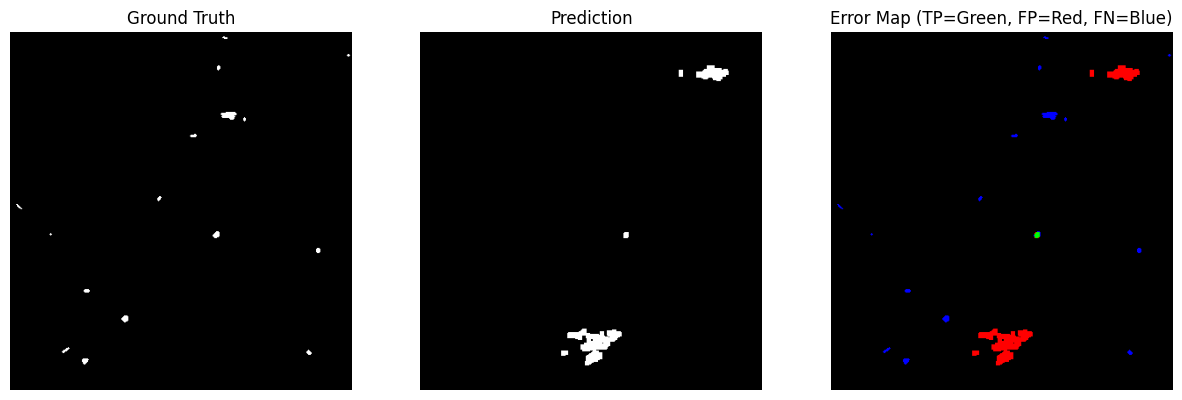

In [10]:
# Error map
error_map = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.uint8)

# Color coding
error_map[(pred == 1) & (gt == 1)] = [0, 255, 0]    # TP - green
error_map[(pred == 1) & (gt == 0)] = [255, 0, 0]    # FP - red
error_map[(pred == 0) & (gt == 1)] = [0, 0, 255]    # FN - blue

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Ground Truth")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Prediction")
plt.imshow(pred, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Error Map (TP=Green, FP=Red, FN=Blue)")
plt.imshow(error_map)
plt.axis("off")

plt.show()
